In [1]:
#  IMPORT
# -----------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy.stats import chi2_contingency

import warnings

warnings.filterwarnings('ignore')

In [2]:
# =============================================================================
# ANALISI SPORT PER CLUSTER SOCIOECONOMICO
# =============================================================================
# Prerequisiti:
#   pip install pandas numpy matplotlib seaborn scipy
#
# File di input:
#   - olympics_dataset.csv        (Kaggle — atleta/sport/medaglia)
#   - olympics_with_clusters.csv  (output di clustering_olimpiadi.py)
#
# File di output:
#   - olympics_sport_cluster.csv  (dataset unito, pronto per ulteriori analisi)
# =============================================================================

In [7]:
#  CARICAMENTO
# -----------------------------------------------------------------------------
kaggle = pd.read_csv('olympics_dataset.csv')
clustered = pd.read_csv('olympics_with_clusters.csv')

print(f"Kaggle:    {kaggle.shape[0]:,} righe × {kaggle.shape[1]} colonne")
print(f"Clustered: {clustered.shape[0]:,} righe × {clustered.shape[1]} colonne")
print()
print("Colonne Kaggle:", kaggle.columns.tolist())
print("Colonne Clustered:", clustered.columns.tolist())

Kaggle:    252,565 righe × 11 colonne
Clustered: 3,368 righe × 25 colonne

Colonne Kaggle: ['player_id', 'Name', 'Sex', 'Team', 'NOC', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal']
Colonne Clustered: ['edition', 'year', 'country', 'noc', 'gold', 'silver', 'bronze', 'total_medals', 'host_country_code', 'host_city', 'gdp_per_capita', 'life_expectancy', 'urbanization_pct', 'population', 'pop_density', 'primary_school_enrollment', 'infant_mortality', 'gdp_total', 'medals_per_million', 'gold_per_million', 'medals_per_gdp_bn', 'won_medal', 'hdi', 'cluster_label', 'cluster']


In [8]:
#  MAPPING NOC — ALLINEAMENTO DEI CODICI PAESE
# -----------------------------------------------------------------------------
# I due dataset usano sistemi di codici diversi in alcuni casi:
#   - Kaggle usa codici IOC (es. NED, SUI, DEN)
#   - Clustered usa in parte codici ISO3 (es. NLD, CHE, DNK)
# Serve anche gestire i paesi storici del Kaggle (es. URS = URSS).
#
# Strategia:
#   1. Mappiamo i codici ISO3 del clustered -> IOC per allinearli al Kaggle
#   2. Per URS (URSS, 2063 medaglie): la assegnamo al cluster di RUS (Russia)
#      perché è la principale entità successore e il dataset socioeconomico
#      usa RUS per il periodo sovietico. Nota questo nella tua tesi/report.

# Mapping ISO3 -> IOC (solo i casi che differiscono)
ISO3_TO_IOC = {
    'ABW': 'ARU',  # Aruba
    'AGO': 'ANG',  # Angola
    'ARE': 'UAE',  # Emirati Arabi
    'ASM': 'ASA',  # Samoa Americane
    'ATG': 'ANT',  # Antigua e Barbuda
    'BFA': 'BUR',  # Burkina Faso
    'BGD': 'BAN',  # Bangladesh
    'BGR': 'BUL',  # Bulgaria
    'BHR': 'BRN',  # Bahrain
    'BHS': 'BAH',  # Bahamas
    'BLZ': 'BIZ',  # Belize
    'BMU': 'BER',  # Bermuda
    'BRB': 'BAR',  # Barbados
    'BTN': 'BHU',  # Bhutan
    'BWA': 'BOT',  # Botswana
    'CHE': 'SUI',  # Svizzera
    'CHL': 'CHI',  # Cile
    'COG': 'CGO',  # Congo
    'CRI': 'CRC',  # Costa Rica
    'CYM': 'CAY',  # Isole Cayman
    'DNK': 'DEN',  # Danimarca
    'DZA': 'ALG',  # Algeria
    'FJI': 'FIJ',  # Figi
    'GIN': 'GUI',  # Guinea
    'GMB': 'GAM',  # Gambia
    'GNB': 'GBS',  # Guinea-Bissau
    'GNQ': 'GEQ',  # Guinea Equatoriale
    'GRC': 'GRE',  # Grecia
    'GRD': 'GRN',  # Grenada
    'GTM': 'GUA',  # Guatemala
    'HND': 'HON',  # Honduras
    'HRV': 'CRO',  # Croazia
    'HTI': 'HAI',  # Haiti
    'IDN': 'INA',  # Indonesia
    'IRN': 'IRI',  # Iran
    'KHM': 'CAM',  # Cambogia
    'KNA': 'SKN',  # Saint Kitts e Nevis
    'KWT': 'KUW',  # Kuwait
    'LBY': 'LBA',  # Libia
    'LKA': 'SRI',  # Sri Lanka
    'LSO': 'LES',  # Lesotho
    'LVA': 'LAT',  # Lettonia
    'MAC': 'MAC',  # Macao (uguale)
    'MCO': 'MON',  # Monaco
    'MDG': 'MAD',  # Madagascar
    'MMR': 'MYA',  # Myanmar
    'MNG': 'MGL',  # Mongolia
    'MRT': 'MTN',  # Mauritania
    'MUS': 'MRI',  # Mauritius
    'MWI': 'MAW',  # Malawi
    'MYS': 'MAS',  # Malaysia
    'NER': 'NIG',  # Niger
    'NGA': 'NGR',  # Nigeria
    'NIC': 'NCA',  # Nicaragua
    'NLD': 'NED',  # Olanda
    'NPL': 'NEP',  # Nepal
    'OMN': 'OMA',  # Oman
    'PHL': 'PHI',  # Filippine
    'PRI': 'PUR',  # Porto Rico
    'PRT': 'POR',  # Portogallo
    'PRY': 'PAR',  # Paraguay
    'PSE': 'PLE',  # Palestina
    'SAU': 'KSA',  # Arabia Saudita
    'SDN': 'SUD',  # Sudan
    'SLV': 'ESA',  # El Salvador
    'SVN': 'SLO',  # Slovenia
    'SYC': 'SEY',  # Seychelles
    'TCD': 'CHA',  # Ciad
    'TZA': 'TAN',  # Tanzania
    'VCT': 'VIN',  # Saint Vincent e Grenadine
    'VUT': 'VAN',  # Vanuatu
    'WSM': 'SAM',  # Samoa
    'ZAF': 'RSA',  # Sudafrica
}

In [9]:
# Applichiamo il mapping al dataset clustered
clustered['noc_ioc'] = clustered['noc'].replace(ISO3_TO_IOC)

In [10]:
# Gestiamo URS (URSS): prendiamo il cluster di RUS e lo usiamo per URS

# Fallback: se il CSV è stato salvato con 'cluster_wb' invece di 'cluster_label'
if 'cluster_label' not in clustered.columns and 'cluster_wb' in clustered.columns:
    clustered = clustered.rename(columns={'cluster_wb': 'cluster_label'})
if 'cluster' not in clustered.columns:
    _cmap = {'Ricchi avanzati': 2, 'Reddito medio-alto': 0,
             'Reddito basso-medio': 1, 'Poveri estremi': 3}
    clustered['cluster'] = clustered['cluster_label'].map(_cmap)

# Gestiamo URS (URSS): prendiamo il cluster di RUS e lo usiamo per URS
rus_cluster = clustered[clustered['noc_ioc'] == 'RUS'][['cluster', 'cluster_label']].iloc[0]
urs_row = pd.DataFrame([{
    'noc_ioc': 'URS',
    'cluster': rus_cluster['cluster'],
    'cluster_label': rus_cluster['cluster_label']
}])

In [11]:
# Tabella di lookup: noc_ioc -> cluster
cluster_lookup = clustered[['noc_ioc', 'cluster', 'cluster_label']].drop_duplicates()
cluster_lookup = pd.concat([cluster_lookup, urs_row], ignore_index=True)
cluster_lookup = cluster_lookup.drop_duplicates(subset='noc_ioc')

print(f"Lookup table creata: {len(cluster_lookup)} paesi con cluster assegnato")

Lookup table creata: 221 paesi con cluster assegnato


In [12]:
# JOIN — UNIONE DEI DUE DATASET
# -----------------------------------------------------------------------------
# Filtriamo solo le medaglie reali (escludiamo 'No medal')
medals = kaggle[kaggle['Medal'] != 'No medal'].copy()
print(f"Medaglie totali nel Kaggle (1896-2024): {len(medals):,}")

# Join su NOC + Year
df = medals.merge(
    cluster_lookup[['noc_ioc', 'cluster', 'cluster_label']],
    left_on='NOC',
    right_on='noc_ioc',
    how='left'
)

Medaglie totali nel Kaggle (1896-2024): 38,818


In [13]:
# Report copertura
matched = df['cluster'].notna().sum()
unmatched = df['cluster'].isna().sum()
print(f"\nMedaglie con cluster assegnato: {matched:,} ({matched/len(df)*100:.1f}%)")
print(f"Medaglie senza cluster:         {unmatched:,} ({unmatched/len(df)*100:.1f}%)")
print()
print("NOC senza cluster (con più medaglie):")
print(
    df[df['cluster'].isna()]
    .groupby('NOC')['Medal'].count()
    .sort_values(ascending=False)
    .head(10)
    .to_string()
)


Medaglie con cluster assegnato: 32,352 (83.3%)
Medaglie senza cluster:         6,466 (16.7%)

NOC senza cluster (con più medaglie):
NOC
NED    1108
GDR     843
DEN     666
FRG     504
SUI     441
YUG     383
BUL     353
TCH     330
GRE     281
EUN     220


In [14]:
# Teniamo solo le righe con cluster assegnato per le analisi
df_clean = df[df['cluster'].notna()].copy()
print(f"\nDataset finale per analisi: {len(df_clean):,} medaglie")


Dataset finale per analisi: 32,352 medaglie


In [15]:
#  PANORAMICA — MEDAGLIE PER CLUSTER
# -----------------------------------------------------------------------------
# Distribuiamo equamente pesando per sport olimpico, non per atleta
# (es. il basket assegna 1 medaglia al paese, non 12)
# Usiamo quindi l'Event come unità: ogni evento/paese/anno = 1 record

event_medals = (
    df_clean.groupby(['Year', 'NOC', 'Sport', 'Event', 'Medal', 'cluster_label'])
    .size()
    .reset_index(name='athletes')  # numero atleti che hanno vinto quell'evento
)

In [16]:
# Per le analisi di frequenza sport, ogni riga = 1 evento vinto
event_medals['count'] = 1

print("=== MEDAGLIE (EVENTI) PER CLUSTER ===")
print(event_medals.groupby('cluster_label')['count'].sum().sort_values(ascending=False).to_string())

print("\n=== SPORT DISTINTI PER CLUSTER ===")
print(event_medals.groupby('cluster_label')['Sport'].nunique().sort_values(ascending=False).to_string())

=== MEDAGLIE (EVENTI) PER CLUSTER ===
cluster_label
Ricchi avanzati        10840
Reddito medio-alto      3708
Reddito basso-medio      622
Poveri estremi            92

=== SPORT DISTINTI PER CLUSTER ===
cluster_label
Ricchi avanzati        70
Reddito medio-alto     55
Reddito basso-medio    31
Poveri estremi          6


In [17]:
#  TOP SPORT PER CLUSTER
# -----------------------------------------------------------------------------
print("=== TOP 10 SPORT PER CLUSTER ===\n")
for label in ['Ricchi avanzati', 'Reddito medio-alto', 'Reddito basso-medio', 'Poveri estremi']:
    subset = event_medals[event_medals['cluster_label'] == label]
    if len(subset) == 0:
        continue
    top = (
        subset.groupby('Sport')['count'].sum()
        .sort_values(ascending=False)
        .head(10)
    )
    total = top.sum()
    print(f"--- {label} ---")
    for sport, n in top.items():
        print(f"  {sport:<25} {n:>4}  ({n/total*100:.1f}%)")
    print()

=== TOP 10 SPORT PER CLUSTER ===

--- Ricchi avanzati ---
  Athletics                 2043  (26.9%)
  Swimming                  1423  (18.7%)
  Wrestling                  672  (8.9%)
  Rowing                     532  (7.0%)
  Fencing                    530  (7.0%)
  Shooting                   529  (7.0%)
  Cycling                    525  (6.9%)
  Boxing                     475  (6.3%)
  Canoeing                   446  (5.9%)
  Sailing                    418  (5.5%)

--- Reddito medio-alto ---
  Athletics                  562  (20.4%)
  Wrestling                  403  (14.6%)
  Gymnastics                 364  (13.2%)
  Boxing                     327  (11.8%)
  Weightlifting              278  (10.1%)
  Shooting                   211  (7.6%)
  Swimming                   184  (6.7%)
  Judo                       169  (6.1%)
  Diving                     143  (5.2%)
  Fencing                    120  (4.3%)

--- Reddito basso-medio ---
  Athletics                  178  (33.1%)
  Wrestling     

In [18]:
#  HEATMAP — SPORT × CLUSTER
# -----------------------------------------------------------------------------
# Calcoliamo la quota (%) di ogni sport sul totale di medaglie del cluster
# Questo normalizza le differenze di dimensione tra cluster

# Top 20 sport per numero totale di medaglie
top_sports = (
    event_medals.groupby('Sport')['count'].sum()
    .sort_values(ascending=False)
    .head(30)
    .index.tolist()
)

pivot = (
    event_medals[event_medals['Sport'].isin(top_sports)]
    .groupby(['cluster_label', 'Sport'])['count']
    .sum()
    .unstack(fill_value=0)
)

In [19]:
# Normalizziamo per riga (% sul totale del cluster)
pivot_pct = pivot.div(pivot.sum(axis=1), axis=0) * 100

# Ordine cluster dal più ricco al più povero
cluster_order = ['Ricchi avanzati', 'Reddito medio-alto', 'Reddito basso-medio', 'Poveri estremi']
pivot_pct = pivot_pct.reindex([c for c in cluster_order if c in pivot_pct.index])


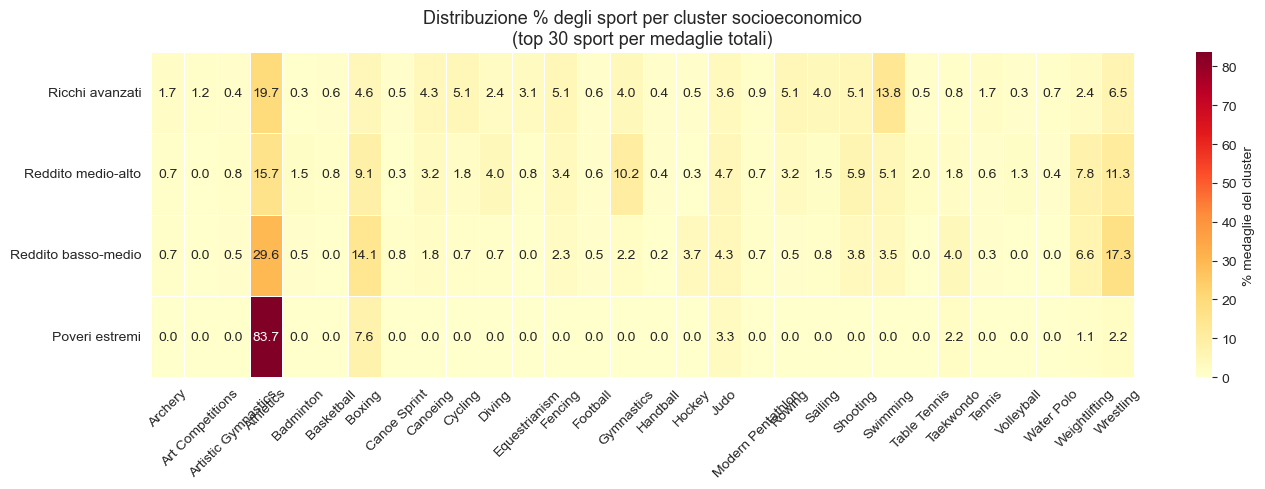

✓ Salvato: heatmap_sport_cluster.png


In [20]:
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    pivot_pct,
    annot=True, fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    cbar_kws={'label': '% medaglie del cluster'}
)
ax.set_title('Distribuzione % degli sport per cluster socioeconomico\n(top 30 sport per medaglie totali)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('heatmap_sport_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: heatmap_sport_cluster.png")

In [21]:
# SPORT DISTINTIVI PER CLUSTER (indice di specializzazione)
# -----------------------------------------------------------------------------
# Calcoliamo quanto uno sport è sovra/sotto-rappresentato in un cluster
# rispetto alla media globale: specialization = (% cluster) / (% globale)
# Valori > 1 = sport più frequente nel cluster rispetto alla media

global_pct = (
    event_medals[event_medals['Sport'].isin(top_sports)]
    .groupby('Sport')['count'].sum()
)
global_pct = global_pct / global_pct.sum() * 100

specialization = pivot_pct.div(global_pct, axis=1)

print("=== INDICE DI SPECIALIZZAZIONE (>1 = sovra-rappresentato) ===\n")
for label in [c for c in cluster_order if c in specialization.index]:
    top3 = specialization.loc[label].sort_values(ascending=False).head(5)
    bot3 = specialization.loc[label].sort_values(ascending=True).head(3)
    print(f"--- {label} ---")
    print("  Sport distintivi:")
    for sport, idx in top3.items():
        print(f"    {sport:<25} indice={idx:.2f}x")
    print("  Sport meno presenti:")
    for sport, idx in bot3.items():
        print(f"    {sport:<25} indice={idx:.2f}x")
    print()


=== INDICE DI SPECIALIZZAZIONE (>1 = sovra-rappresentato) ===

--- Ricchi avanzati ---
  Sport distintivi:
    Art Competitions          indice=1.41x
    Equestrianism             indice=1.30x
    Cycling                   indice=1.25x
    Tennis                    indice=1.24x
    Sailing                   indice=1.24x
  Sport meno presenti:
    Badminton                 indice=0.51x
    Table Tennis              indice=0.60x
    Volleyball                indice=0.61x

--- Reddito medio-alto ---
  Sport distintivi:
    Badminton                 indice=2.46x
    Table Tennis              indice=2.36x
    Volleyball                indice=2.33x
    Weightlifting             indice=2.02x
    Gymnastics                indice=1.88x
  Sport meno presenti:
    Art Competitions          indice=0.00x
    Equestrianism             indice=0.33x
    Cycling                   indice=0.44x

--- Reddito basso-medio ---
  Sport distintivi:
    Hockey                    indice=6.28x
    Taekwondo      

In [22]:
# TEST CHI-QUADRO — LA DISTRIBUZIONE DEGLI SPORT DIPENDE DAL CLUSTER?
# -----------------------------------------------------------------------------
# H0: la distribuzione degli sport è indipendente dal cluster
# H1: esiste una relazione tra cluster socioeconomico e sport in cui si vince

contingency = (
    event_medals[event_medals['Sport'].isin(top_sports)]
    .groupby(['cluster_label', 'Sport'])['count']
    .sum()
    .unstack(fill_value=0)
)

chi2, p_value, dof, expected = chi2_contingency(contingency)

print("=== TEST CHI-QUADRO ===")
print(f"Chi²  = {chi2:.2f}")
print(f"p-value = {p_value:.2e}")
print(f"Gradi di libertà = {dof}")
print()
if p_value < 0.05:
    print("✓ Risultato: p < 0.05 — rifiutiamo H0.")
    print("  La distribuzione degli sport è significativamente diversa tra cluster.")
    print("  Esiste una relazione tra condizione socioeconomica e sport olimpici vinti.")
else:
    print("✗ Risultato: p >= 0.05 — non rifiutiamo H0.")
    print("  Non c'è evidenza sufficiente di una relazione.")

=== TEST CHI-QUADRO ===
Chi²  = 2070.06
p-value = 0.00e+00
Gradi di libertà = 87

✓ Risultato: p < 0.05 — rifiutiamo H0.
  La distribuzione degli sport è significativamente diversa tra cluster.
  Esiste una relazione tra condizione socioeconomica e sport olimpici vinti.


In [23]:
# EVOLUZIONE TEMPORALE — I CLUSTER CAMBIANO NEL TEMPO?
# -----------------------------------------------------------------------------
# Vediamo se la quota di medaglie di ogni cluster è cambiata nel corso delle edizioni

time_cluster = (
    event_medals[event_medals['Year'] >= 1964]
    .groupby(['Year', 'cluster_label'])['count']
    .sum()
    .unstack(fill_value=0)
)

In [24]:
# Normalizziamo per riga (% per anno)
time_cluster_pct = time_cluster.div(time_cluster.sum(axis=1), axis=0) * 100

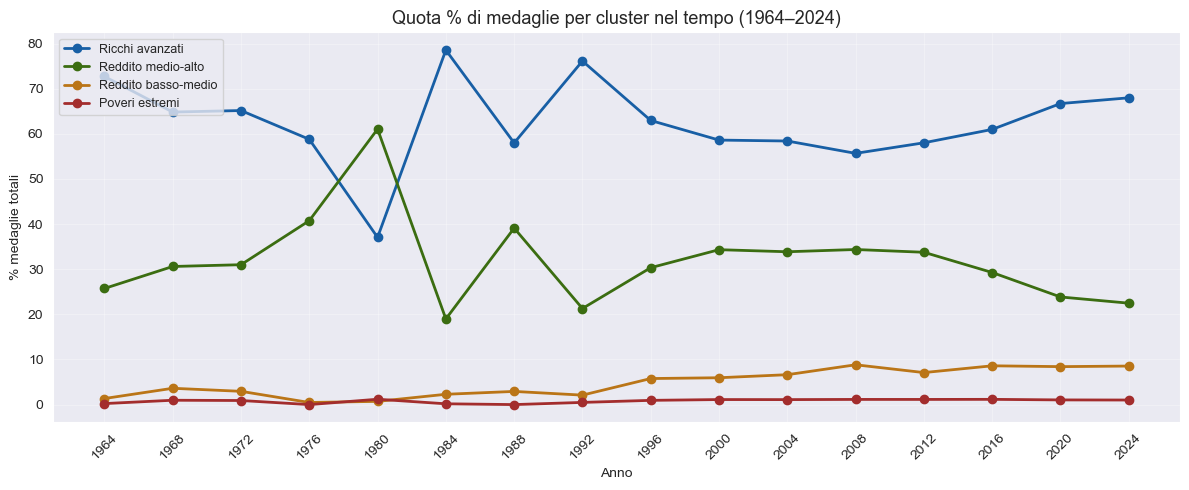

✓ Salvato: evoluzione_cluster_tempo.png


In [25]:
fig, ax = plt.subplots(figsize=(12, 5))
colors = {'Ricchi avanzati': '#185FA5', 'Reddito medio-alto': '#3B6D11',
          'Reddito basso-medio': '#BA7517', 'Poveri estremi': '#A32D2D'}

for col in [c for c in cluster_order if c in time_cluster_pct.columns]:
    ax.plot(
        time_cluster_pct.index,
        time_cluster_pct[col],
        marker='o', linewidth=2,
        label=col, color=colors.get(col, 'gray')
    )

ax.set_title('Quota % di medaglie per cluster nel tempo (1964–2024)', fontsize=13)
ax.set_xlabel('Anno')
ax.set_ylabel('% medaglie totali')
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
ax.set_xticks(time_cluster_pct.index)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.savefig('evoluzione_cluster_tempo.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: evoluzione_cluster_tempo.png")

In [26]:
# SALVATAGGIO DATASET FINALE
# -----------------------------------------------------------------------------
df_clean.to_csv('olympics_sport_cluster.csv', index=False)
print(f"\n✓ Salvato: olympics_sport_cluster.csv")
print(f"   {len(df_clean):,} medaglie con sport, anno, NOC e cluster socioeconomico")
print("\nColonne disponibili:")
print(df_clean.columns.tolist())


✓ Salvato: olympics_sport_cluster.csv
   32,352 medaglie con sport, anno, NOC e cluster socioeconomico

Colonne disponibili:
['player_id', 'Name', 'Sex', 'Team', 'NOC', 'Year', 'Season', 'City', 'Sport', 'Event', 'Medal', 'noc_ioc', 'cluster', 'cluster_label']


# CAMBIO DI PROSPETTIVA


CELLE AGGIUNTIVE — PROSPETTIVA "PER SPORT"
Chi domina ogni disciplina olimpica?

 Da aggiungere in fondo ad analisi_sport_cluster.py
 Prerequisito: event_medals, pivot, cluster_order già definiti nelle celle precedenti

  HEATMAP NORMALIZZATA PER SPORT

 Ogni colonna somma a 100%: mostra quale cluster domina ogni singolo sport.
 Complementare alla cella [7] dove ogni riga sommava a 100%.

In [27]:
pivot_pct_col = pivot.div(pivot.sum(axis=0), axis=1) * 100

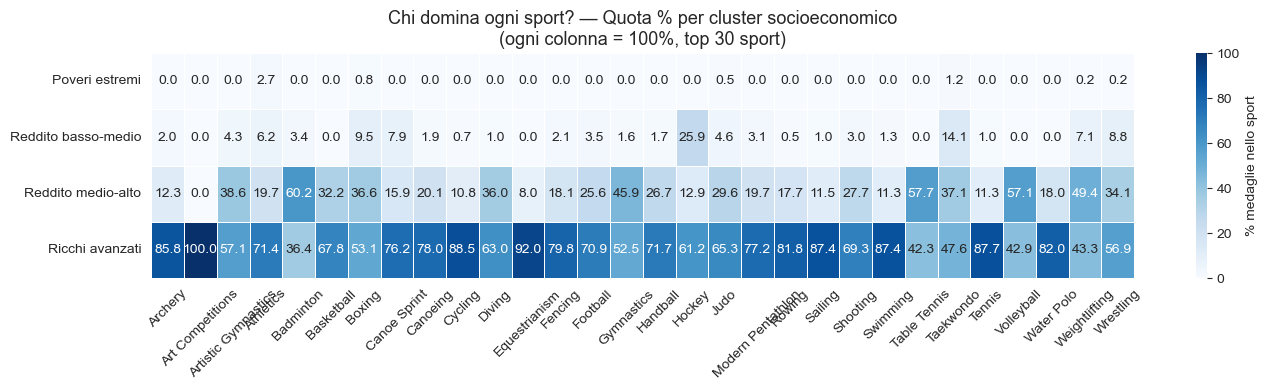

✓ Salvato: heatmap_chi_domina_sport.png


In [28]:
fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(
    pivot_pct_col,
    annot=True, fmt='.1f',
    cmap='Blues',
    linewidths=0.5,
    ax=ax,
    vmin=0, vmax=100,
    cbar_kws={'label': '% medaglie nello sport'}
)
ax.set_title(
    'Chi domina ogni sport? — Quota % per cluster socioeconomico\n'
    '(ogni colonna = 100%, top 30 sport)',
    fontsize=13
)
ax.set_xlabel('')
ax.set_ylabel('')
ax.tick_params(axis='x', rotation=45)
ax.tick_params(axis='y', rotation=0)
plt.tight_layout()
plt.savefig('heatmap_chi_domina_sport.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: heatmap_chi_domina_sport.png")

In [29]:
#  SPORT PIÙ E MENO "DEMOCRATICI"
# -----------------------------------------------------------------------------
# Definiamo "democraticità" di uno sport come la quota di medaglie
# vinta dai cluster NON ricchi (medio-alto + basso-medio + poveri estremi).
# Più alto il valore, più lo sport è accessibile a paesi meno sviluppati.

non_rich_clusters = ['Reddito medio-alto', 'Reddito basso-medio', 'Poveri estremi']
non_rich_share = (
    pivot_pct_col
    .reindex([c for c in non_rich_clusters if c in pivot_pct_col.index])
    .sum(axis=0)
    .sort_values(ascending=False)
)

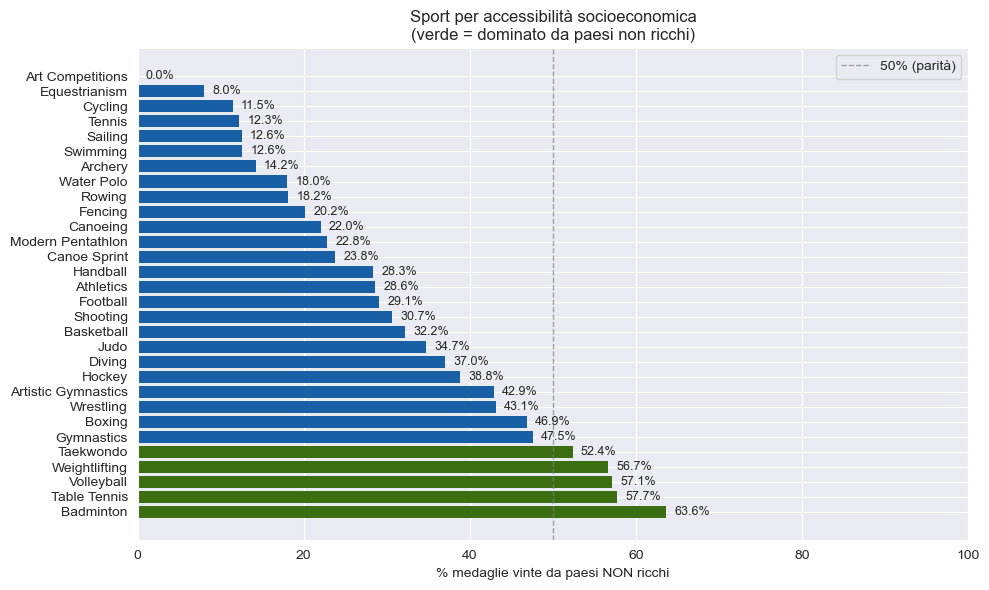

✓ Salvato: sport_accessibilita.png

=== SPORT PIÙ ACCESSIBILI (dominati da paesi non ricchi) ===
Sport
Badminton        63.636364
Table Tennis     57.723577
Volleyball       57.142857
Weightlifting    56.660746
Taekwondo        52.352941

=== SPORT MENO ACCESSIBILI (dominati da paesi ricchi) ===
Sport
Art Competitions      0.000000
Equestrianism         8.045977
Cycling              11.467116
Tennis               12.254902
Sailing              12.552301
Swimming             12.592138
Archery              14.215686
Water Polo           17.977528
Rowing               18.153846
Fencing              20.180723
Canoeing             22.027972
Modern Pentathlon    22.834646
Canoe Sprint         23.809524
Handball             28.333333
Athletics            28.566434
Football             29.069767


In [30]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#3B6D11' if v >= 50 else '#185FA5' for v in non_rich_share.values]
bars = ax.barh(non_rich_share.index, non_rich_share.values, color=colors, edgecolor='none')

ax.axvline(50, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='50% (parità)')
ax.set_xlabel('% medaglie vinte da paesi NON ricchi')
ax.set_title('Sport per accessibilità socioeconomica\n(verde = dominato da paesi non ricchi)', fontsize=12)
ax.legend()
ax.set_xlim(0, 100)

for bar, val in zip(bars, non_rich_share.values):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('sport_accessibilita.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: sport_accessibilita.png")

print("\n=== SPORT PIÙ ACCESSIBILI (dominati da paesi non ricchi) ===")
print(non_rich_share[non_rich_share >= 50].to_string())
print("\n=== SPORT MENO ACCESSIBILI (dominati da paesi ricchi) ===")
print(non_rich_share[non_rich_share < 30].sort_values().to_string())

In [31]:
#  STACKED BAR — COMPOSIZIONE DI OGNI SPORT PER CLUSTER
# -----------------------------------------------------------------------------
# Una barra per sport, divisa per cluster: permette di leggere
# rapidamente la "firma socioeconomica" di ogni disciplina.

colors_cluster = {
    'Ricchi avanzati':      '#185FA5',
    'Reddito medio-alto':   '#3B6D11',
    'Reddito basso-medio':  '#BA7517',
    'Poveri estremi':       '#A32D2D',
}

In [32]:
# Ordiniamo gli sport per quota "ricchi avanzati" (dal più esclusivo al meno)
sport_order = pivot_pct_col.loc['Ricchi avanzati'].sort_values(ascending=True).index.tolist()
data_ordered = pivot_pct_col[sport_order]

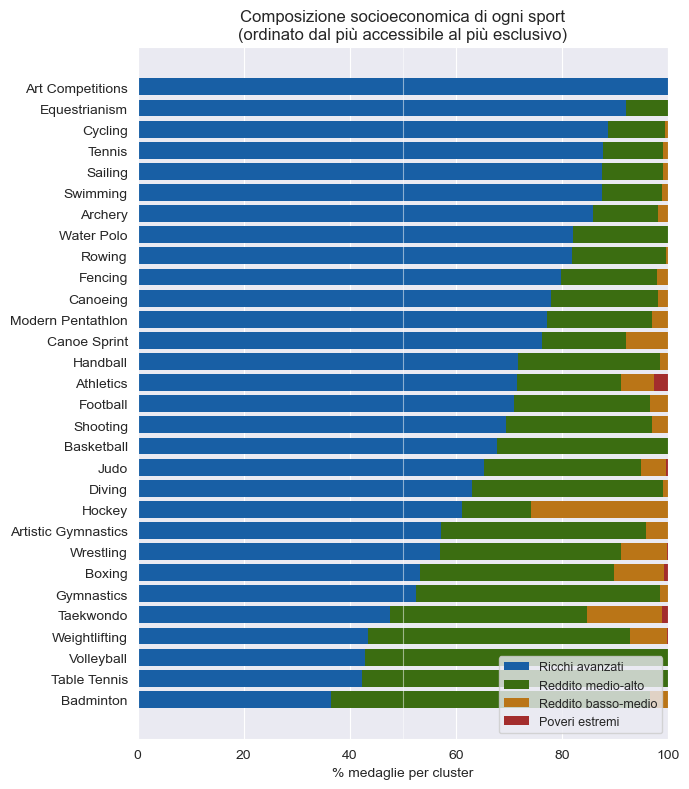

✓ Salvato: composizione_sport_cluster.png


In [33]:
fig, ax = plt.subplots(figsize=(7,8))
bottom = np.zeros(len(sport_order))

for label in [c for c in cluster_order if c in data_ordered.index]:
    values = data_ordered.loc[label].values
    ax.barh(
        sport_order, values, left=bottom,
        color=colors_cluster[label], label=label, edgecolor='none'
    )
    bottom += values

ax.set_xlabel('% medaglie per cluster')
ax.set_title(
    'Composizione socioeconomica di ogni sport\n'
    '(ordinato dal più accessibile al più esclusivo)',
    fontsize=12
)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim(0, 100)
ax.axvline(50, color='white', linewidth=0.8, alpha=0.5)
plt.tight_layout()
plt.savefig('composizione_sport_cluster.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Salvato: composizione_sport_cluster.png")

In [34]:
clusters = (
    df.groupby('cluster_label')['NOC']
      .apply(lambda x: sorted(set(x)))
      .to_dict()
)